In [25]:
#Importação e carregamento do dataset
import pandas as pd

df = pd.read_csv("wine_quality_merged.csv")

print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

df.head()

Quantidade de linhas: 6497
Quantidade de colunas: 13


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


# Nova seção

In [26]:
#Visualização inicial do dataset
print("Informações do dataset")
df.info()

print("\nValores nulos por coluna")
print(df.isnull().sum())

print("\nRegistros duplicados")
print(df.duplicated().sum())

print("\nResumo estatístico")
df.describe().T

Informações do dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB

Valores nulos por coluna
fixed acidity 

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [27]:
#Informações das colunas
quantidade_antes = df.shape[0]

df = df.drop_duplicates().reset_index(drop=True)

quantidade_depois = df.shape[0]

print("Registros antes da remoção:", quantidade_antes)
print("Registros duplicados removidos:", quantidade_antes - quantidade_depois)
print("Registros após a remoção:", quantidade_depois)

Registros antes da remoção: 6497
Registros duplicados removidos: 1177
Registros após a remoção: 5320


In [28]:
#Criação dos valores nulos artificiais
import numpy as np

colunas_com_nulos = [
    "alcohol",
    "pH",
    "residual sugar",
    "chlorides",
    "type"
]

for numero, coluna in enumerate(colunas_com_nulos):
    indices = df.sample(n=53, random_state=42 + numero).index
    df.loc[indices, coluna] = np.nan

print("Valores nulos nas colunas selecionadas")
print(df[colunas_com_nulos].isnull().sum())

print("\nTotal de células com valores nulos:", df.isnull().sum().sum())

Valores nulos nas colunas selecionadas
alcohol           53
pH                53
residual sugar    53
chlorides         53
type              53
dtype: int64

Total de células com valores nulos: 265


In [29]:
#Criação e análise da variável-alvo
def classificar_qualidade(nota):
    if nota <= 4:
        return "Ruim"
    elif nota <= 6:
        return "Médio"
    else:
        return "Bom"

df["quality_class"] = df["quality"].apply(classificar_qualidade)

ordem_classes = ["Ruim", "Médio", "Bom"]

quantidade_classes = (
    df["quality_class"]
    .value_counts()
    .reindex(ordem_classes)
)

percentual_classes = (
    df["quality_class"]
    .value_counts(normalize=True)
    .reindex(ordem_classes)
    .mul(100)
    .round(2)
)

distribuicao_classes = pd.DataFrame({
    "Quantidade": quantidade_classes,
    "Percentual": percentual_classes
})

distribuicao_classes

,Quantidade,Percentual
quality_class,,
Ruim,236,4.44
Médio,4075,76.60
Bom,1009,18.97


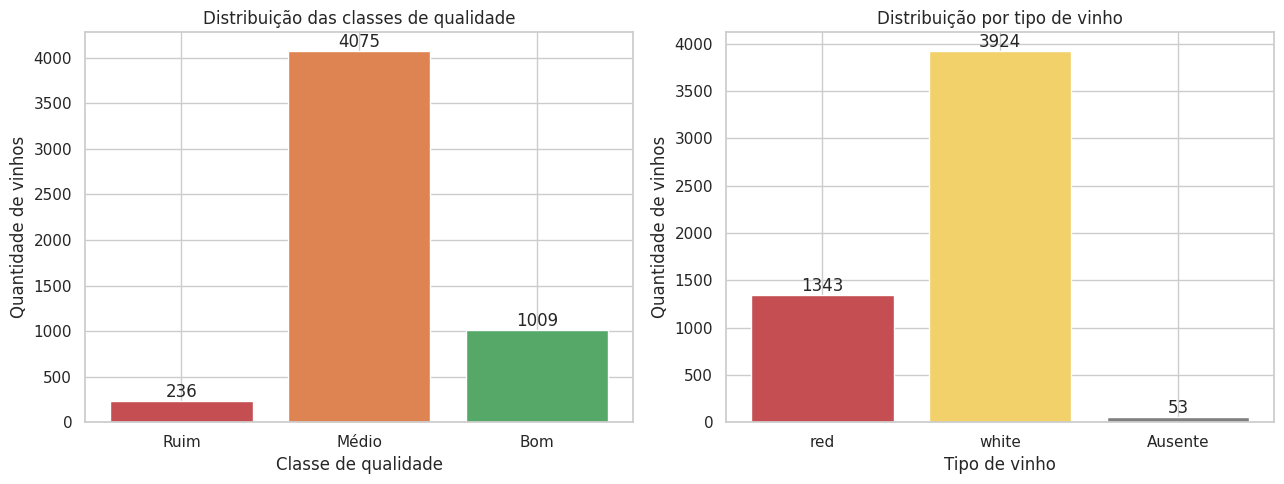

In [30]:
#Visualização da distribuição dos dados
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

quantidade_tipos = (
    df["type"]
    .fillna("Ausente")
    .value_counts()
    .reindex(["red", "white", "Ausente"])
)

fig, graficos = plt.subplots(1, 2, figsize=(13, 5))

graficos[0].bar(
    quantidade_classes.index,
    quantidade_classes.values,
    color=["#c44e52", "#dd8452", "#55a868"]
)

graficos[0].set_title("Distribuição das classes de qualidade")
graficos[0].set_xlabel("Classe de qualidade")
graficos[0].set_ylabel("Quantidade de vinhos")
graficos[0].bar_label(graficos[0].containers[0])

graficos[1].bar(
    quantidade_tipos.index,
    quantidade_tipos.values,
    color=["#c44e52", "#f2d16b", "#808080"]
)

graficos[1].set_title("Distribuição por tipo de vinho")
graficos[1].set_xlabel("Tipo de vinho")
graficos[1].set_ylabel("Quantidade de vinhos")
graficos[1].bar_label(graficos[1].containers[0])

plt.tight_layout()
plt.show()

In [31]:
#Identificação dos valores extremos
colunas_numericas = df.drop(
    columns=["quality", "quality_class", "type"]
).columns

resultado_outliers = []

for coluna in colunas_numericas:
    primeiro_quartil = df[coluna].quantile(0.25)
    terceiro_quartil = df[coluna].quantile(0.75)
    intervalo_interquartil = terceiro_quartil - primeiro_quartil

    limite_inferior = primeiro_quartil - 1.5 * intervalo_interquartil
    limite_superior = terceiro_quartil + 1.5 * intervalo_interquartil

    quantidade_outliers = (
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ).sum()

    resultado_outliers.append({
        "Atributo": coluna,
        "Limite inferior": round(limite_inferior, 4),
        "Limite superior": round(limite_superior, 4),
        "Valores extremos": quantidade_outliers
    })

tabela_outliers = pd.DataFrame(resultado_outliers)

tabela_outliers

,Atributo,Limite inferior,Limite superior,Valores extremos
0,fixed acidity,4.4500,9.6500,304
1,volatile acidity,-0.0400,0.6800,279
2,citric acid,-0.0000,0.6400,143
3,residual sugar,-6.7500,16.0500,140
4,chlorides,-0.0040,0.1080,233
5,free sulfur dioxide,-21.5000,78.5000,44
6,total sulfur dioxide,-44.8750,272.1250,10
7,density,0.9853,1.0036,3
8,pH,2.8050,3.6450,63
9,sulphates,0.1750,0.8550,163


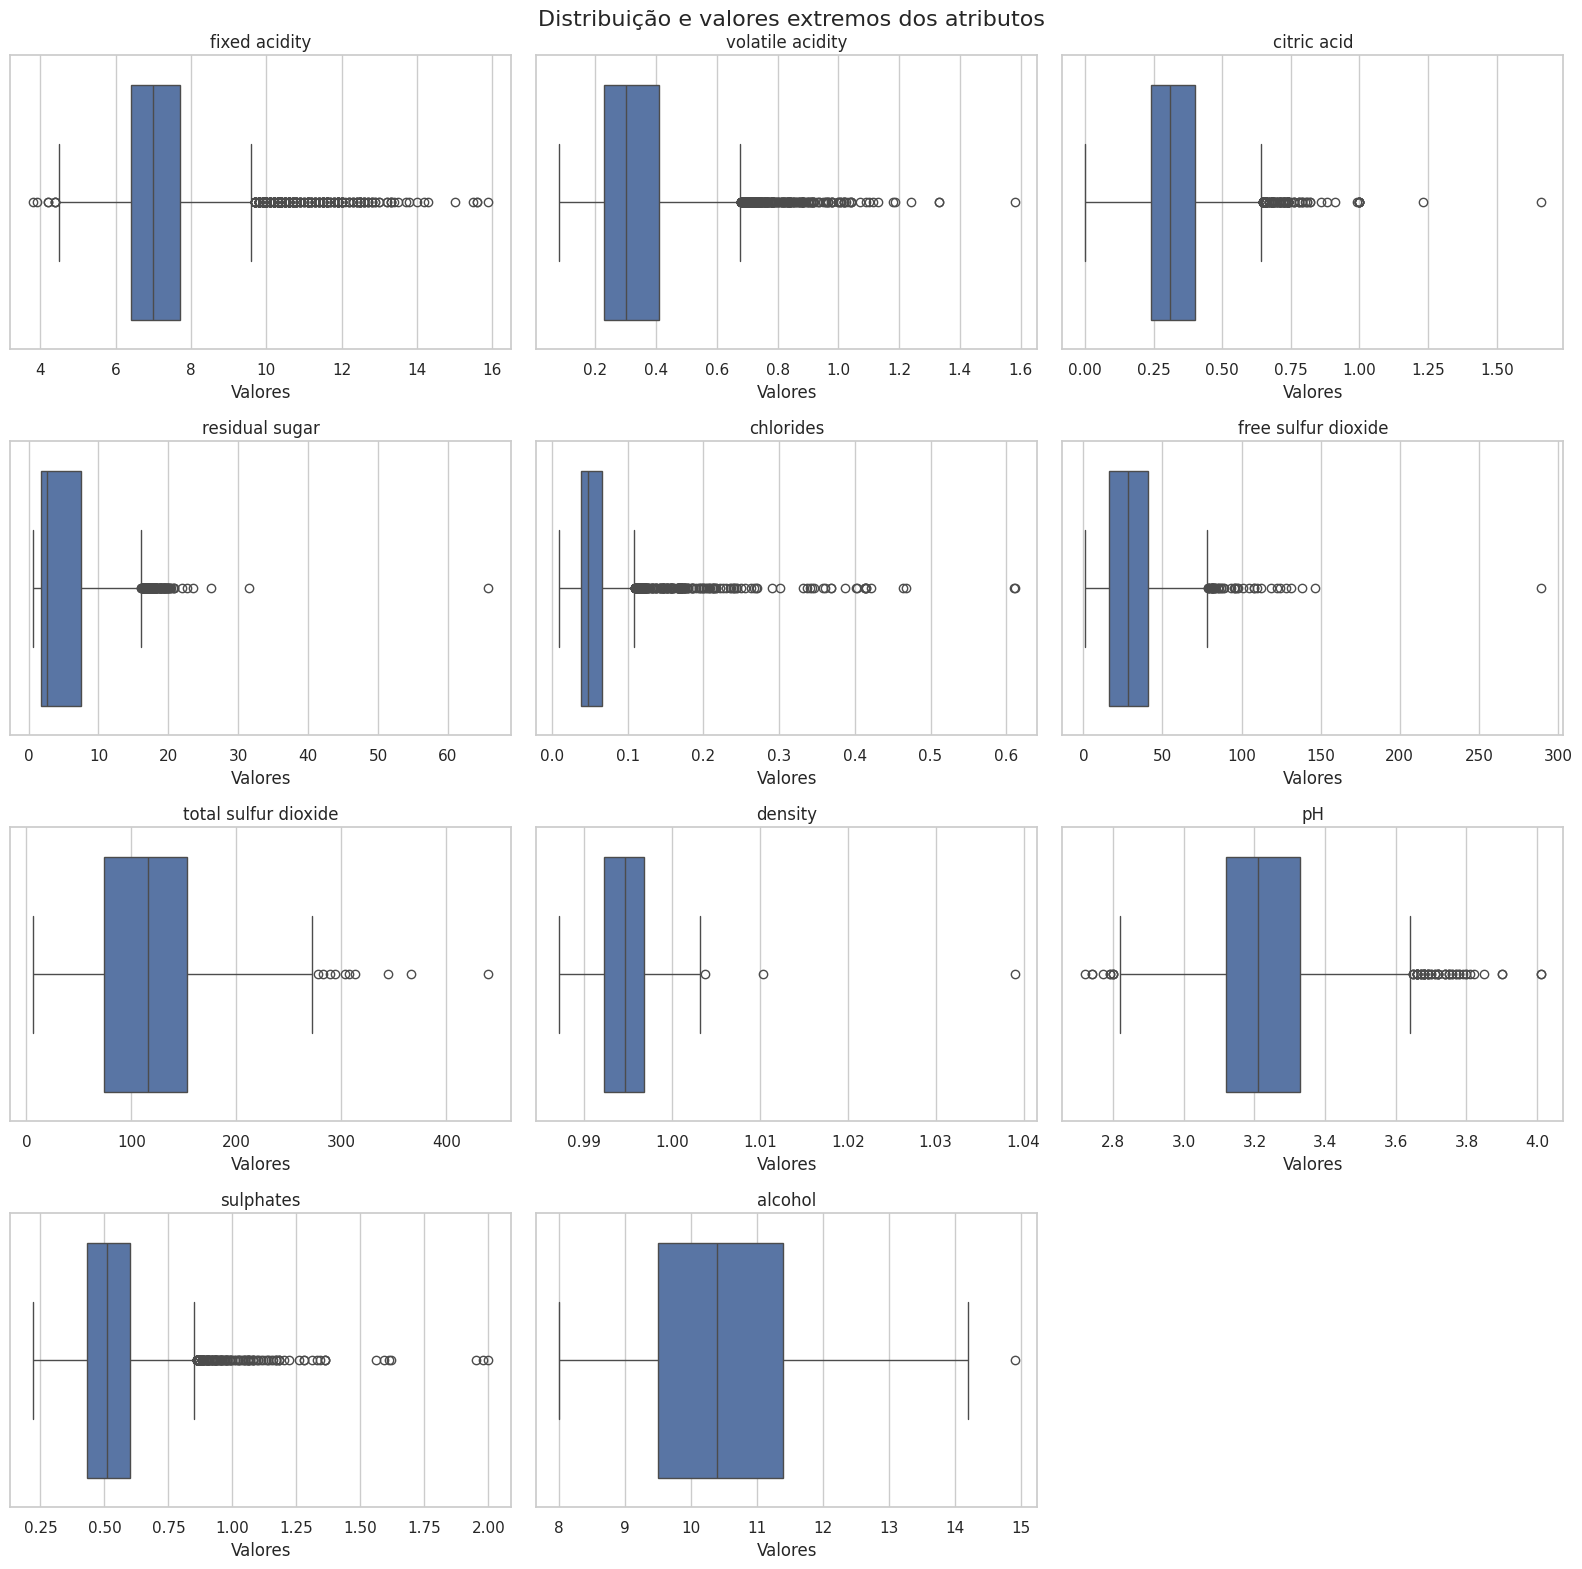

In [32]:
#Visualização dos valores extremos
fig, graficos = plt.subplots(4, 3, figsize=(16, 16))

graficos = graficos.flatten()

for indice, coluna in enumerate(colunas_numericas):
    sns.boxplot(
        x=df[coluna],
        ax=graficos[indice],
        color="#4c72b0"
    )

    graficos[indice].set_title(coluna)
    graficos[indice].set_xlabel("Valores")

for indice in range(len(colunas_numericas), len(graficos)):
    graficos[indice].set_visible(False)

fig.suptitle(
    "Distribuição e valores extremos dos atributos",
    fontsize=16
)

plt.tight_layout()
plt.show()

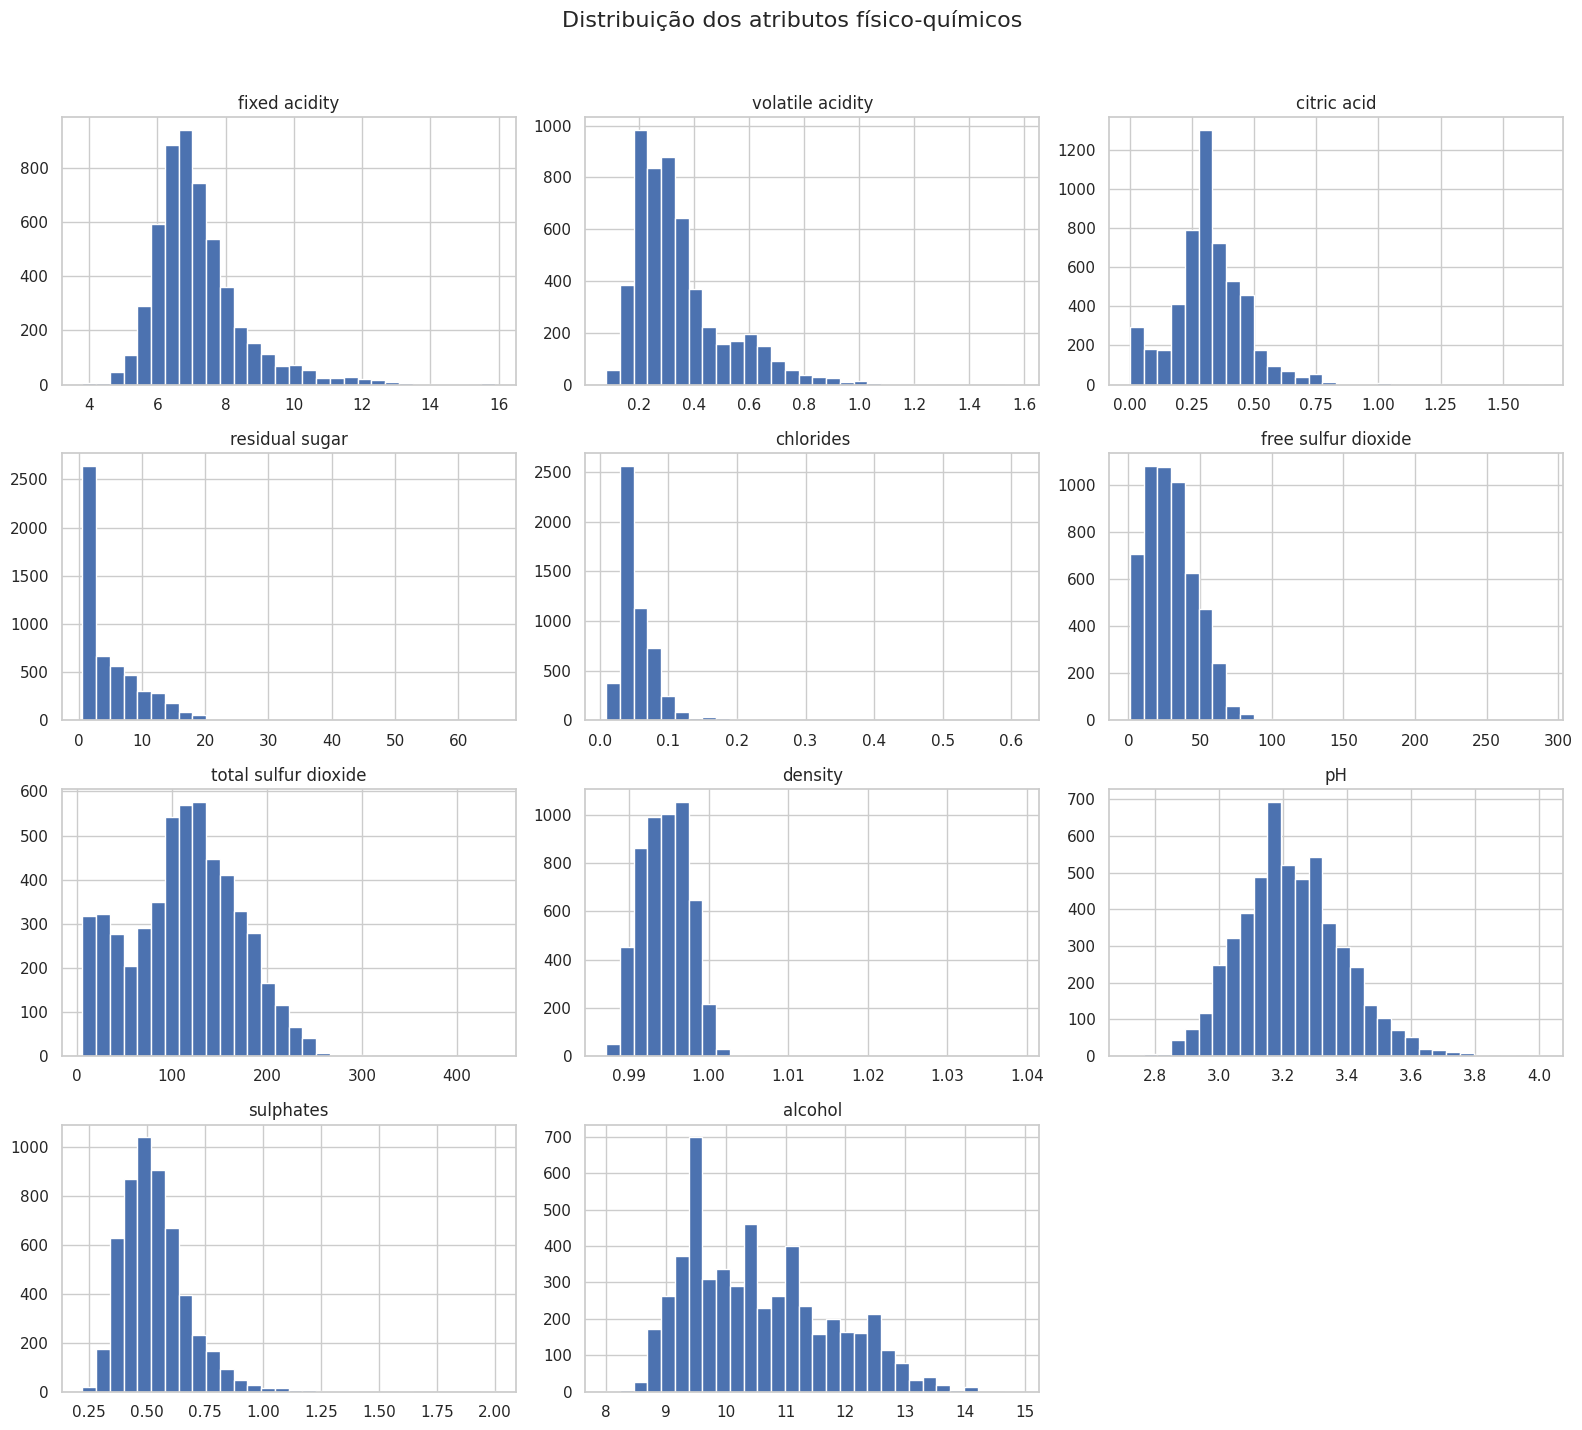

In [33]:
#Histogramas dos atributos físico-químicos
df[colunas_numericas].hist(
    bins=30,
    figsize=(16, 14),
    color="#4c72b0",
    edgecolor="white"
)

plt.suptitle(
    "Distribuição dos atributos físico-químicos",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

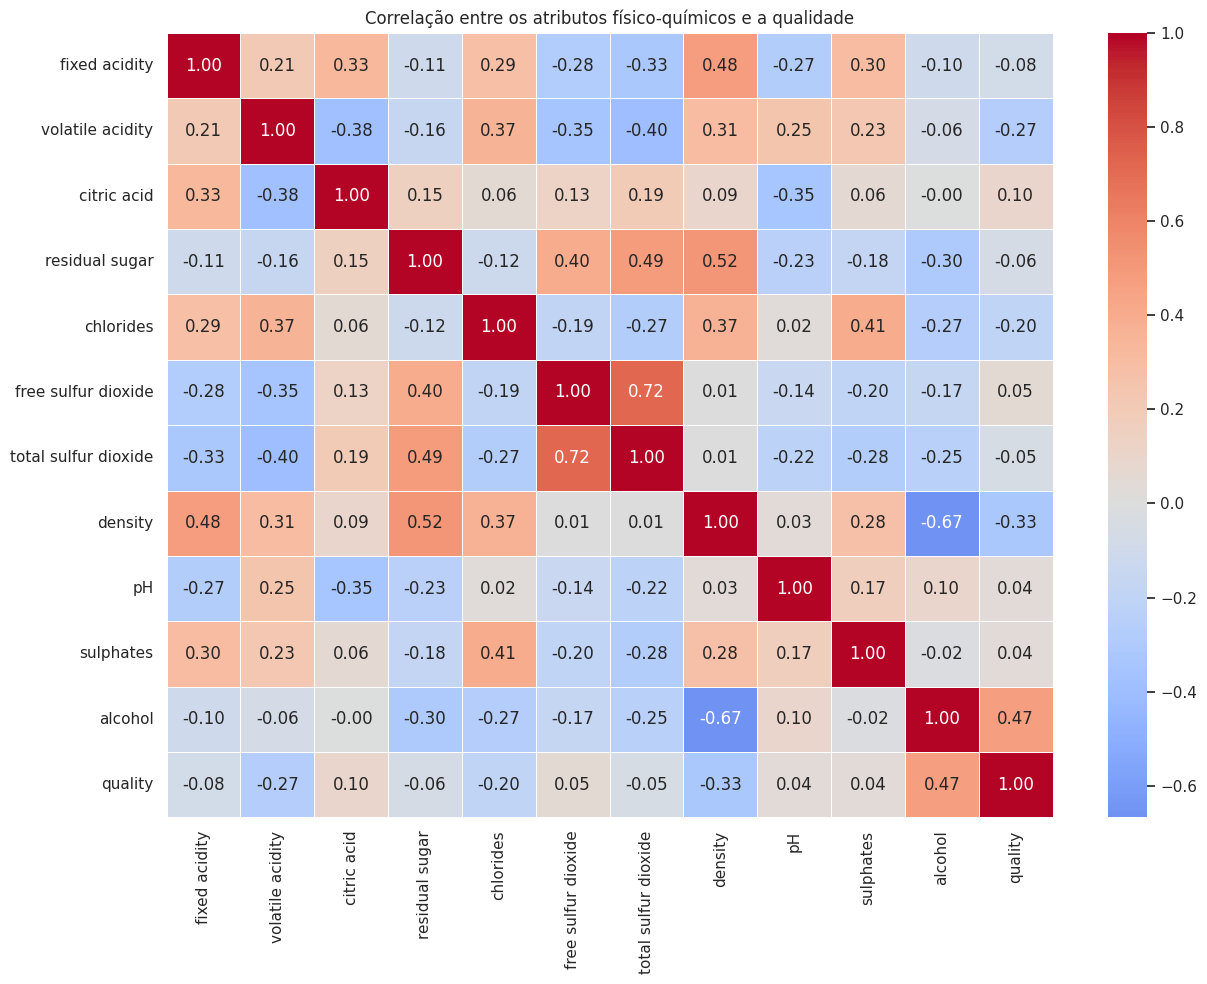

In [34]:
#Matriz de correlação
colunas_correlacao = list(colunas_numericas) + ["quality"]

matriz_correlacao = df[colunas_correlacao].corr()

plt.figure(figsize=(13, 10))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlação entre os atributos físico-químicos e a qualidade")
plt.tight_layout()
plt.show()

In [35]:
#Divisão dos dados
from sklearn.model_selection import train_test_split

X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

divisao_dados = pd.DataFrame({
    "Conjunto": ["Treinamento", "Validação", "Teste"],
    "Proporção": ["70%", "15%", "15%"],
    "Quantidade": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ]
})

divisao_dados

,Conjunto,Proporção,Quantidade
0,Treinamento,70%,3724
1,Validação,15%,798
2,Teste,15%,798


In [36]:
#Construção do pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

colunas_media = ["alcohol", "pH"]
colunas_mediana = ["residual sugar", "chlorides"]
colunas_categoricas = ["type"]

colunas_numericas_restantes = [
    coluna for coluna in colunas_numericas
    if coluna not in colunas_media + colunas_mediana
]

pipeline_media = Pipeline([
    ("preenchimento", SimpleImputer(strategy="mean")),
    ("padronizacao", StandardScaler())
])

pipeline_mediana = Pipeline([
    ("preenchimento", SimpleImputer(strategy="median")),
    ("padronizacao", StandardScaler())
])

pipeline_numerico = Pipeline([
    ("padronizacao", StandardScaler())
])

pipeline_categorico = Pipeline([
    ("preenchimento", SimpleImputer(strategy="most_frequent")),
    (
        "codificacao",
        OneHotEncoder(
            drop="if_binary",
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

pre_processamento = ColumnTransformer([
    ("media", pipeline_media, colunas_media),
    ("mediana", pipeline_mediana, colunas_mediana),
    ("numericos", pipeline_numerico, colunas_numericas_restantes),
    ("categorica", pipeline_categorico, colunas_categoricas)
])

X_train_processado = pre_processamento.fit_transform(X_train)

print("Formato dos dados processados:", X_train_processado.shape)
print("Valores nulos após o processamento:", np.isnan(X_train_processado).sum())

Formato dos dados processados: (3724, 12)
Valores nulos após o processamento: 0


In [37]:
#Treinamento e otimização do KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipeline_knn = Pipeline([
    ("pre_processamento", pre_processamento),
    ("modelo", KNeighborsClassifier())
])

parametros_knn = {
    "modelo__n_neighbors": [3, 5, 7, 9, 11, 15],
    "modelo__weights": ["uniform", "distance"],
    "modelo__metric": ["euclidean", "manhattan"]
}

validacao_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

busca_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=parametros_knn,
    scoring="f1_macro",
    cv=validacao_cruzada,
    n_jobs=-1
)

busca_knn.fit(X_train, y_train)

print("Melhores hiperparâmetros do KNN:")
print(busca_knn.best_params_)

print("\nMelhor F1-score macro na validação cruzada:")
print(round(busca_knn.best_score_, 4))

Melhores hiperparâmetros do KNN:
{'modelo__metric': 'euclidean', 'modelo__n_neighbors': 3, 'modelo__weights': 'distance'}

Melhor F1-score macro na validação cruzada:
0.5025


In [24]:
#Treinamento e otimização do Random Forest
from sklearn.ensemble import RandomForestClassifier

pipeline_random_forest = Pipeline([
    ("pre_processamento", pre_processamento),
    (
        "modelo",
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

parametros_random_forest = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [None, 10, 20, 30],
    "modelo__min_samples_leaf": [1, 2, 4]
}

busca_random_forest = GridSearchCV(
    estimator=pipeline_random_forest,
    param_grid=parametros_random_forest,
    scoring="f1_macro",
    cv=validacao_cruzada,
    n_jobs=-1
)

busca_random_forest.fit(X_train, y_train)

print("Melhores hiperparâmetros do Random Forest:")
print(busca_random_forest.best_params_)

print("\nMelhor F1-score macro na validação cruzada:")
print(round(busca_random_forest.best_score_, 4))

Melhores hiperparâmetros do Random Forest:
{'modelo__max_depth': 10, 'modelo__min_samples_leaf': 4, 'modelo__n_estimators': 300}

Melhor F1-score macro na validação cruzada:
0.5663


In [38]:
#Comparação dos modelos na base de validação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

melhor_knn = busca_knn.best_estimator_
melhor_random_forest = busca_random_forest.best_estimator_

def calcular_metricas_validacao(modelo, nome):
    previsoes = modelo.predict(X_validation)
    probabilidades = modelo.predict_proba(X_validation)
    classes = modelo.named_steps["modelo"].classes_

    return {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_validation, previsoes),
        "Precisão macro": precision_score(
            y_validation,
            previsoes,
            average="macro",
            zero_division=0
        ),
        "Recall macro": recall_score(
            y_validation,
            previsoes,
            average="macro",
            zero_division=0
        ),
        "F1-score macro": f1_score(
            y_validation,
            previsoes,
            average="macro",
            zero_division=0
        ),
        "ROC-AUC macro": roc_auc_score(
            y_validation,
            probabilidades,
            multi_class="ovr",
            average="macro",
            labels=classes
        )
    }

resultados_validacao = pd.DataFrame([
    calcular_metricas_validacao(melhor_knn, "KNN"),
    calcular_metricas_validacao(
        melhor_random_forest,
        "Random Forest"
    )
])

resultados_validacao.round(4)

,Modelo,Acurácia,Precisão macro,Recall macro,F1-score macro,ROC-AUC macro
0,KNN,0.7995,0.6484,0.5262,0.5524,0.7482
1,Random Forest,0.7469,0.5353,0.5312,0.5161,0.8116


In [39]:
# Treinamento final e avaliação no conjunto de teste
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

X_train_final = pd.concat(
    [X_train, X_validation],
    ignore_index=True
)

y_train_final = pd.concat(
    [y_train, y_validation],
    ignore_index=True
)

modelo_knn_final = clone(melhor_knn)
modelo_random_forest_final = clone(melhor_random_forest)

modelo_knn_final.fit(X_train_final, y_train_final)
modelo_random_forest_final.fit(X_train_final, y_train_final)

def calcular_metricas_teste(modelo, nome):
    previsoes = modelo.predict(X_test)
    probabilidades = modelo.predict_proba(X_test)
    classes = modelo.named_steps["modelo"].classes_

    return {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, previsoes),
        "Precisão macro": precision_score(
            y_test,
            previsoes,
            average="macro",
            zero_division=0
        ),
        "Recall macro": recall_score(
            y_test,
            previsoes,
            average="macro",
            zero_division=0
        ),
        "F1-score macro": f1_score(
            y_test,
            previsoes,
            average="macro",
            zero_division=0
        ),
        "ROC-AUC macro": roc_auc_score(
            y_test,
            probabilidades,
            multi_class="ovr",
            average="macro",
            labels=classes
        )
    }

resultados_teste = pd.DataFrame([
    calcular_metricas_teste(modelo_knn_final, "KNN"),
    calcular_metricas_teste(
        modelo_random_forest_final,
        "Random Forest"
    )
])

resultados_teste.round(4)

,Modelo,Acurácia,Precisão macro,Recall macro,F1-score macro,ROC-AUC macro
0,KNN,0.7707,0.582,0.5210,0.5438,0.7468
1,Random Forest,0.7644,0.676,0.5988,0.6048,0.8455


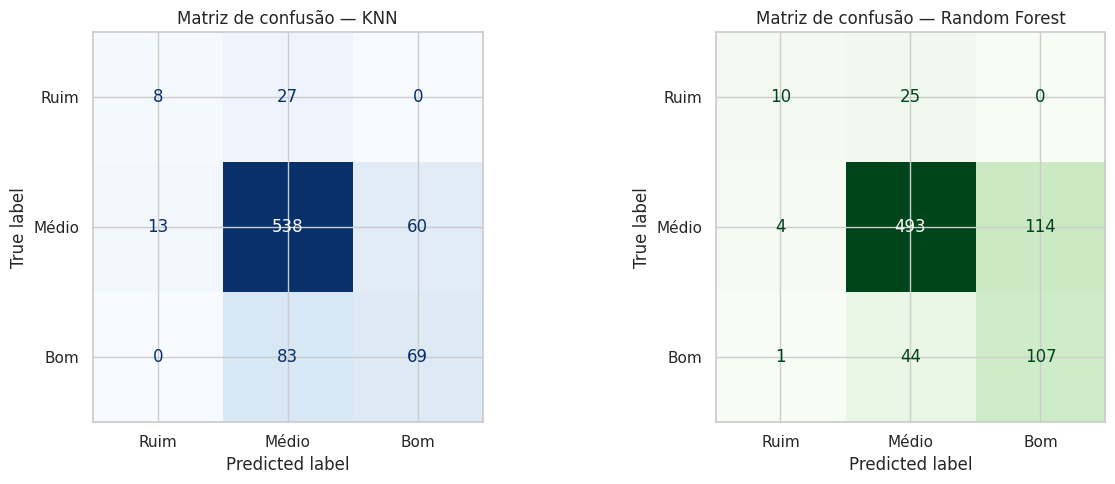

In [40]:
# Matrizes de confusão dos modelos
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

previsoes_knn = modelo_knn_final.predict(X_test)
previsoes_random_forest = modelo_random_forest_final.predict(X_test)

ordem_classes = ["Ruim", "Médio", "Bom"]

matriz_knn = confusion_matrix(
    y_test,
    previsoes_knn,
    labels=ordem_classes
)

matriz_random_forest = confusion_matrix(
    y_test,
    previsoes_random_forest,
    labels=ordem_classes
)

fig, graficos = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_knn,
    display_labels=ordem_classes
).plot(
    ax=graficos[0],
    cmap="Blues",
    colorbar=False
)

graficos[0].set_title("Matriz de confusão — KNN")

ConfusionMatrixDisplay(
    confusion_matrix=matriz_random_forest,
    display_labels=ordem_classes
).plot(
    ax=graficos[1],
    cmap="Greens",
    colorbar=False
)

graficos[1].set_title("Matriz de confusão — Random Forest")

plt.tight_layout()
plt.show()

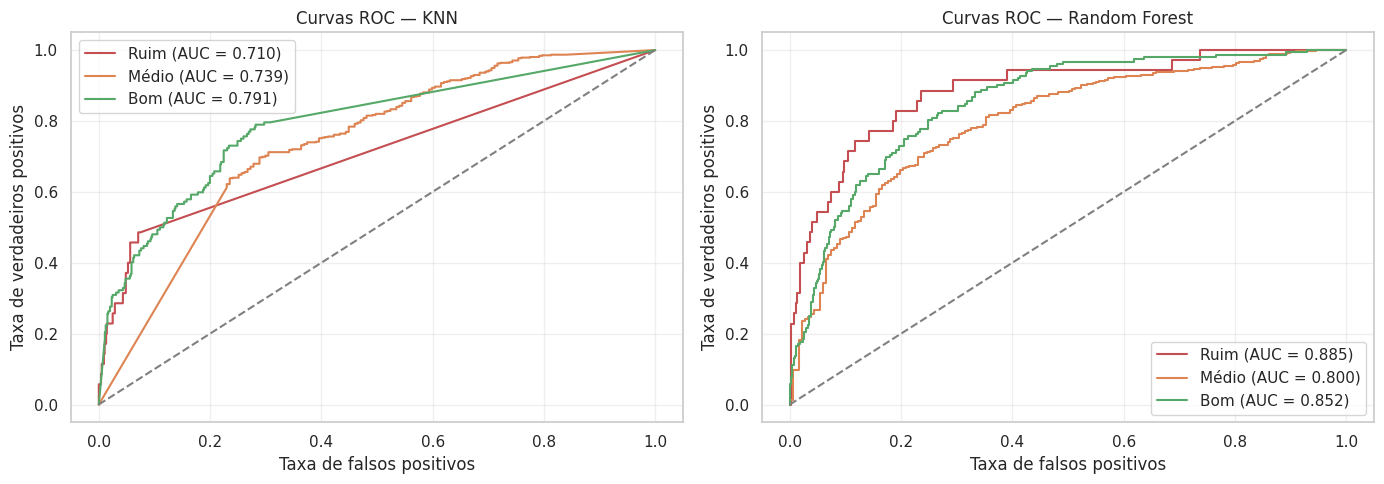

In [41]:
# Curvas ROC dos modelos
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

ordem_classes = ["Ruim", "Médio", "Bom"]

y_test_binario = label_binarize(
    y_test,
    classes=ordem_classes
)

def preparar_probabilidades(modelo):
    probabilidades = modelo.predict_proba(X_test)
    classes_modelo = list(
        modelo.named_steps["modelo"].classes_
    )

    indices = [
        classes_modelo.index(classe)
        for classe in ordem_classes
    ]

    return probabilidades[:, indices]

probabilidades_knn = preparar_probabilidades(
    modelo_knn_final
)

probabilidades_random_forest = preparar_probabilidades(
    modelo_random_forest_final
)

fig, graficos = plt.subplots(1, 2, figsize=(14, 5))

modelos = [
    ("KNN", probabilidades_knn),
    ("Random Forest", probabilidades_random_forest)
]

cores = ["#c44e52", "#dd8452", "#55a868"]

for grafico, (nome, probabilidades) in zip(
    graficos,
    modelos
):
    for indice, classe in enumerate(ordem_classes):
        taxa_falsos_positivos, taxa_verdadeiros_positivos, _ = (
            roc_curve(
                y_test_binario[:, indice],
                probabilidades[:, indice]
            )
        )

        valor_auc = auc(
            taxa_falsos_positivos,
            taxa_verdadeiros_positivos
        )

        grafico.plot(
            taxa_falsos_positivos,
            taxa_verdadeiros_positivos,
            color=cores[indice],
            label=f"{classe} (AUC = {valor_auc:.3f})"
        )

    grafico.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray"
    )

    grafico.set_title(f"Curvas ROC — {nome}")
    grafico.set_xlabel("Taxa de falsos positivos")
    grafico.set_ylabel("Taxa de verdadeiros positivos")
    grafico.legend()
    grafico.grid(alpha=0.3)

plt.tight_layout()
plt.show()

,Atributo,Importância
0,alcohol,0.1671
7,free sulfur dioxide,0.1220
5,volatile acidity,0.1172
9,density,0.0964
8,total sulfur dioxide,0.0804
10,sulphates,0.0797
3,chlorides,0.0761
6,citric acid,0.0656
2,residual sugar,0.0620
1,pH,0.0612


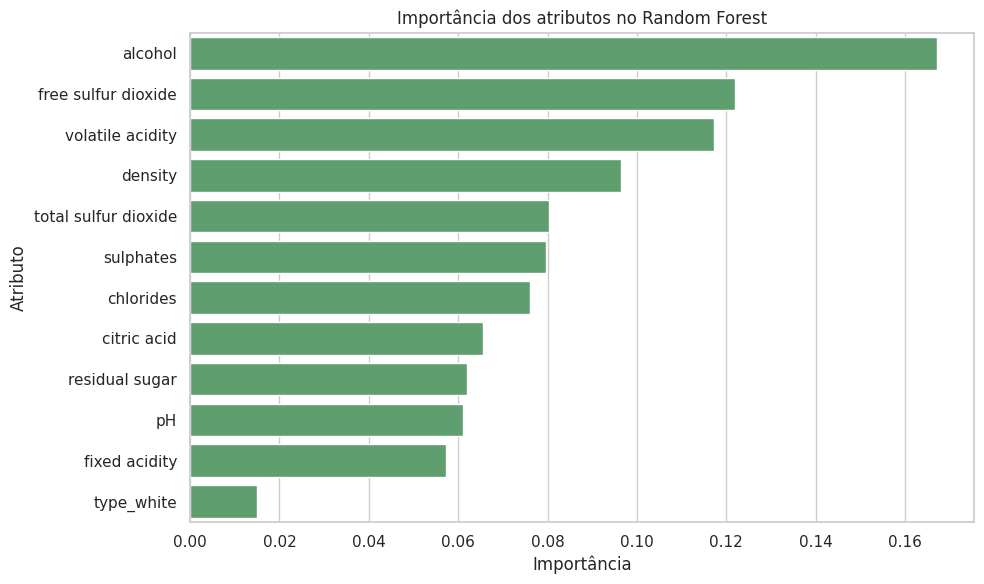

In [42]:
# Importância dos atributos do Random Forest
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

processador_final = modelo_random_forest_final.named_steps[
    "pre_processamento"
]

random_forest_final = modelo_random_forest_final.named_steps[
    "modelo"
]

nomes_atributos = processador_final.get_feature_names_out()

nomes_atributos = [
    nome.split("__")[-1]
    for nome in nomes_atributos
]

importancia_atributos = pd.DataFrame({
    "Atributo": nomes_atributos,
    "Importância": random_forest_final.feature_importances_
}).sort_values(
    by="Importância",
    ascending=False
)

display(importancia_atributos.round(4))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancia_atributos,
    x="Importância",
    y="Atributo",
    color="#55a868"
)

plt.title("Importância dos atributos no Random Forest")
plt.xlabel("Importância")
plt.ylabel("Atributo")
plt.tight_layout()
plt.show()

In [43]:
# Salvamento do modelo final
import joblib

nome_arquivo = "modelo_qualidade_vinho.pkl"

joblib.dump(
    modelo_random_forest_final,
    nome_arquivo
)

print("Modelo final salvo com sucesso:")
print(nome_arquivo)

Modelo final salvo com sucesso:
modelo_qualidade_vinho.pkl


In [44]:
# Validação do modelo salvo
import joblib
import pandas as pd

modelo_carregado = joblib.load(
    "modelo_qualidade_vinho.pkl"
)

amostra_teste = X_test.iloc[[0]]
classe_real = y_test.iloc[0]

classe_prevista = modelo_carregado.predict(
    amostra_teste
)[0]

probabilidades = modelo_carregado.predict_proba(
    amostra_teste
)[0]

classes_modelo = modelo_carregado.named_steps[
    "modelo"
].classes_

resultado_probabilidades = pd.DataFrame({
    "Classe": classes_modelo,
    "Probabilidade": probabilidades
})

resultado_probabilidades["Probabilidade"] = (
    resultado_probabilidades["Probabilidade"] * 100
).round(2)

print("Classe real:", classe_real)
print("Classe prevista:", classe_prevista)

display(
    resultado_probabilidades.sort_values(
        by="Probabilidade",
        ascending=False
    )
)

Classe real: Médio
Classe prevista: Médio


,Classe,Probabilidade
1,Médio,64.13
2,Ruim,20.56
0,Bom,15.31


In [45]:
# Download do modelo final
from google.colab import files

files.download("modelo_qualidade_vinho.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
# Especificações técnicas do ambiente
import sys
import platform
import subprocess
import shutil
import psutil
import sklearn
import pandas
import numpy
import matplotlib
import seaborn
import joblib

caminho_nvidia_smi = shutil.which("nvidia-smi")

if caminho_nvidia_smi:
    resultado_gpu = subprocess.run(
        [
            caminho_nvidia_smi,
            "--query-gpu=name",
            "--format=csv,noheader"
        ],
        capture_output=True,
        text=True
    )

    nome_gpu = (
        resultado_gpu.stdout.strip()
        or "GPU não identificada"
    )
else:
    nome_gpu = "GPU não utilizada ou não disponível"

especificacoes_tecnicas = pd.DataFrame({
    "Item": [
        "Sistema operacional",
        "Versão do Python",
        "Processador",
        "Memória RAM",
        "GPU",
        "Pandas",
        "NumPy",
        "Scikit-learn",
        "Matplotlib",
        "Seaborn",
        "Joblib"
    ],
    "Especificação": [
        platform.platform(),
        sys.version.split()[0],
        platform.processor() or platform.machine(),
        f"{psutil.virtual_memory().total / (1024 ** 3):.2f} GB",
        nome_gpu,
        pandas.__version__,
        numpy.__version__,
        sklearn.__version__,
        matplotlib.__version__,
        seaborn.__version__,
        joblib.__version__
    ]
})

especificacoes_tecnicas

,Item,Especificação
0,Sistema operacional,Linux-6.6.122+-x86_64-with-glibc2.39
1,Versão do Python,3.13.15
2,Processador,x86_64
3,Memória RAM,12.67 GB
4,GPU,GPU não utilizada ou não disponível
5,Pandas,2.2.3
6,NumPy,2.1.3
7,Scikit-learn,1.6.1
8,Matplotlib,3.10.0
9,Seaborn,0.13.2


In [48]:
# Criação do arquivo de dependências
from google.colab import files

conteudo_requirements = f"""pandas=={pandas.__version__}
numpy=={numpy.__version__}
scikit-learn=={sklearn.__version__}
matplotlib=={matplotlib.__version__}
seaborn=={seaborn.__version__}
joblib=={joblib.__version__}
psutil=={psutil.__version__}
"""

with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as arquivo:
    arquivo.write(conteudo_requirements)

print(conteudo_requirements)

files.download("requirements.txt")

pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
matplotlib==3.10.0
seaborn==0.13.2
joblib==1.6.0
psutil==5.9.5



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>